<a href="https://colab.research.google.com/github/Aishwaryaselvaraju/Credit-Scoring-Model/blob/main/Credit_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project:** Credit Scoring Model using Machine Learning

**Dataset Source:** German Credit Data Dataset (Kaggle)

**Description:** This project aims to predict whether a customer is a **Good Credit Risk** or **Bad Credit Risk** based on their financial and personal information. The dataset includes customer details such as **Age, Sex, Job, Housing, Saving Accounts, Checking Account, Credit Amount, Duration, and Purpose**. The project involves data preprocessing techniques including missing value handling, categorical data encoding, and feature scaling. Machine learning classification algorithms such as **Logistic Regression**, **Decision Tree Classifier**, and **Support Vector Machine (SVM)** are trained to classify customer credit risk. The project also includes exploratory data analysis (EDA), data visualization, model evaluation using **Accuracy Score, Classification Report, ROC-AUC Score, and Confusion Matrix**, comparison of model performance, and model saving using Joblib for future predictions.

**Tools Used:** Python, Google Colab, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, LabelEncoder, StandardScaler, Logistic Regression, Decision Tree Classifier, Support Vector Machine (SVM), Joblib

Install Required Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

import joblib

Upload Dataset

In [27]:
from google.colab import files

uploaded = files.upload()

Saving german_credit_data.csv to german_credit_data (3).csv


Load Dataset

In [28]:
df = pd.read_csv("german_credit_data (3).csv")

View Dataset

In [29]:
print(df.columns)

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


In [30]:
df.columns.tolist()

['Unnamed: 0',
 'Age',
 'Sex',
 'Job',
 'Housing',
 'Saving accounts',
 'Checking account',
 'Credit amount',
 'Duration',
 'Purpose',
 'Risk']

In [31]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,Good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,Bad
2,2,49,male,1,own,little,NaN,2096,12,education,Good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,Bad
4,4,53,male,2,free,little,little,4870,24,car,Good


Dataset Information

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


Check Missing Values

In [33]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


Remove Unnecessary Column

In [34]:
df.drop("Unnamed: 0", axis=1, inplace=True)

Fill Missing Values

In [35]:
df.fillna("Unknown", inplace=True)

Display Dataset

In [36]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,Unknown,little,1169,6,radio/TV,Good
1,22,female,2,own,little,moderate,5951,48,radio/TV,Bad
2,49,male,1,own,little,Unknown,2096,12,education,Good
3,45,male,2,free,little,little,7882,42,furniture/equipment,Bad
4,53,male,2,free,little,little,4870,24,car,Good


Encode Categorical Columns

In [37]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

Feature Scaling

In [38]:
scaler = StandardScaler()

numerical_columns = [
    "Age",
    "Credit amount",
    "Duration"
]

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

Separate Features and Target

Target Column - Risk

In [39]:
X = df.drop("Risk", axis=1)

y = df["Risk"]

Split Dataset

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

Train Logistic Regression

In [41]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

Predict

In [42]:
y_pred_lr = lr.predict(X_test)

Accuracy

In [43]:
accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", accuracy)

Accuracy : 0.9733333333333334


Classification Report

In [44]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94        73
           1       0.98      0.99      0.98       227

    accuracy                           0.97       300
   macro avg       0.97      0.96      0.96       300
weighted avg       0.97      0.97      0.97       300



ROC AUC Score

In [45]:
roc = roc_auc_score(y_test, y_pred_lr)

print("ROC AUC Score :", roc)

ROC AUC Score : 0.9591454951421157


Confusion Matrix

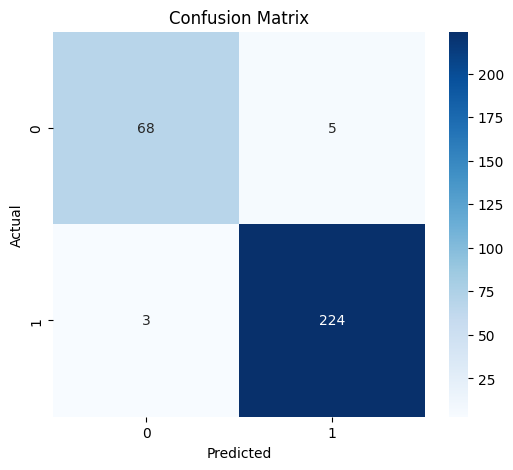

In [46]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Decision Tree

In [47]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy")

print(accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00       227

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



Support Vector Machine

In [48]:
svm = SVC(probability=True)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy")

print(accuracy_score(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

SVM Accuracy
0.98
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        73
           1       0.98      0.99      0.99       227

    accuracy                           0.98       300
   macro avg       0.98      0.97      0.97       300
weighted avg       0.98      0.98      0.98       300



Compare Models

In [49]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Support Vector Machine"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_svm)
    ]

})

results

,Model,Accuracy
0,Logistic Regression,0.973333
1,Decision Tree,1.000000
2,Support Vector Machine,0.980000


Accuracy Graph

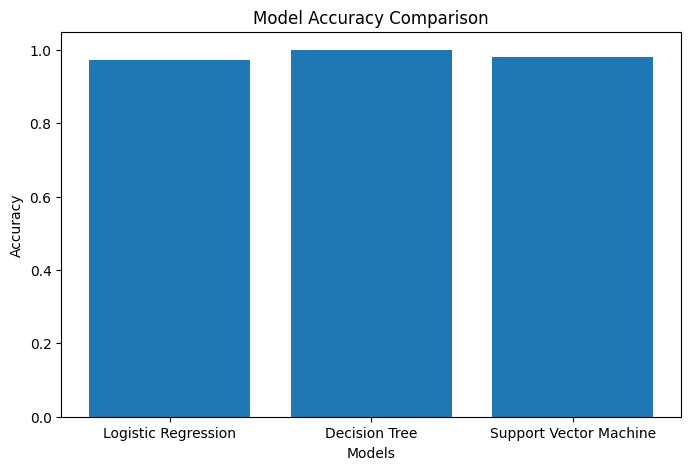

In [50]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"],results["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

Save Model

In [51]:
joblib.dump(lr,"credit_scoring_model.pkl")

['credit_scoring_model.pkl']

Load Saved Model

In [52]:
model = joblib.load("credit_scoring_model.pkl")

Predict New Customer

In [53]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print(prediction)

[1]


Testing

In [54]:
new_customer = pd.DataFrame({
    "Age": [30],
    "Sex": [1],
    "Job": [2],
    "Housing": [1],
    "Saving accounts": [2],
    "Checking account": [1],
    "Credit amount": [3000],
    "Duration": [12],
    "Purpose": [3]
})

prediction = lr.predict(new_customer)

print(prediction)

[0]


Simple testing


In [55]:
sample = X_test.iloc[[0]]
print(lr.predict(sample))

[1]
